In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

from CNN import OUT_DIR, XRAY_DIR, CSV_PATH

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    rename_map = {
        "Image Index": "IMGPATH",
        "Finding Labels": "DISEASELABEL",
        "Follow-up #": "FOLLOWUP",
        "Patient ID": "PATID",
        "Patient Age": "AGE",
        "Patient Gender": "GENDER",
        "View Position": "VP",
    }
    df = df.rename(columns=rename_map)
    return df

def find_full_path(image_name):
    for subdir in os.listdir(XRAY_DIR):
        full_path = os.path.join(XRAY_DIR, subdir, image_name)
        if os.path.exists(full_path):
            return full_path
    return None

def assign_multilabel_vector(df, class_list):
    def create_vector(labels):
        return [int(cls in labels) for cls in class_list]
    df["MULTIHOT"] = df["DISEASELABEL"].apply(create_vector)
    df = df[[
        "IMGPATH",
        "DISEASELABEL",
        "MULTIHOT",
        "FOLLOWUP",
        "PATID",
        "AGE",
        "GENDER",
        "VP",
    ]]
    return df

def patient_aware_split(df, test_size=0.08, val_size=0.12):
    no_findings = df[df["DISEASELABEL"].apply(lambda x: x == ["No Finding"])]
    findings = df[df["DISEASELABEL"].apply(lambda x: "No Finding" not in x)]

    df_balanced = pd.concat([findings, no_findings.sample(frac=0.3, random_state=42)])
    unique_patients = df_balanced["PATID"].unique()

    train_val_patients, test_patients = train_test_split(
        unique_patients, test_size=test_size, random_state=42
    )
    train_patients, val_patients = train_test_split(
        train_val_patients, test_size=val_size / (1 - test_size), random_state=42
    )
    train_df = df_balanced[df_balanced["PATID"].isin(train_patients)]
    val_df = df_balanced[df_balanced["PATID"].isin(val_patients)]
    test_df = df_balanced[df_balanced["PATID"].isin(test_patients)]
    return train_df, val_df, test_df


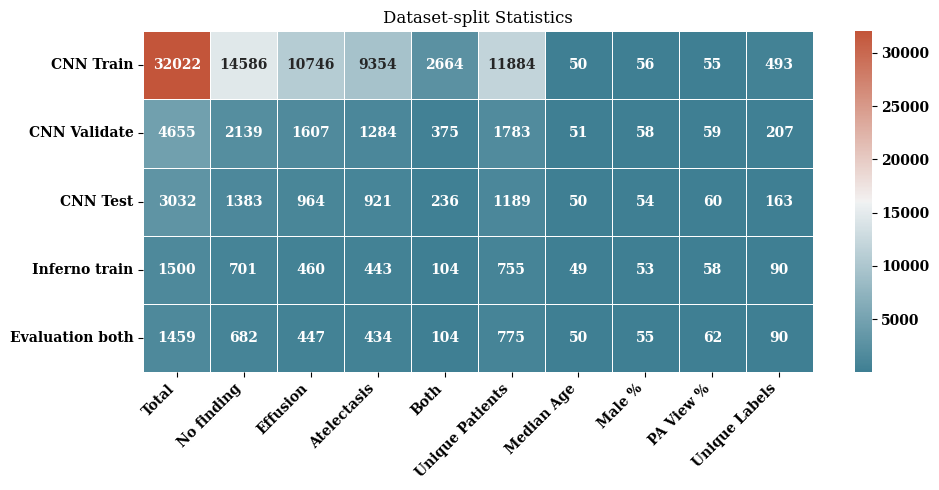

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path

from CNN import OUT_DIR, CALIB_DIR


def generate_split_statistics_heatmap(
    csv_paths: list[Path], labels: list[str], output_file: Path
):
    assert len(csv_paths) == len(labels), "Each CSV must have a corresponding label"

    def multilabel_stats(df, name):
        return pd.Series(
            {
                "Total": len(df),
                "No finding": df["MULTIHOT"]
                .apply(lambda x: x[0] == 0 and x[1] == 0)
                .sum(),
                "Effusion": df["MULTIHOT"].apply(lambda x: x[0]).sum(),
                "Atelectasis": df["MULTIHOT"].apply(lambda x: x[1]).sum(),
                "Both": df["MULTIHOT"].apply(lambda x: x[0] == 1 and x[1] == 1).sum(),
                "Unique Patients": df["PATID"].nunique(),
                "Median Age": df["AGE"].median(),
                "Male %": (df["GENDER"] == "M").mean() * 100,
                "PA View %": (df["VP"] == "PA").mean() * 100,
                "Unique Labels": df["DISEASELABEL"].apply(str).nunique(),
            },
            name=name,
        )

    all_stats = []
    for csv_path, label in zip(csv_paths, labels):
        df = pd.read_csv(csv_path)
        df["MULTIHOT"] = df["MULTIHOT"].apply(eval)
        all_stats.append(multilabel_stats(df, label))

    summary_df = pd.concat(all_stats, axis=1).T
    heatmap_data = summary_df.astype(int)

    matplotlib.rcParams["font.family"] = "Serif"

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )

    ax.set_title("Dataset-split Statistics")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    fig.savefig(output_file)
    display(fig)
    plt.close(fig)


generate_split_statistics_heatmap(
    [
        OUT_DIR / "ml_train.csv",
        OUT_DIR / "ml_val.csv",
        OUT_DIR / "ml_test.csv",
        CALIB_DIR / "calibration_train.csv",
        CALIB_DIR / "calibration_test.csv",
    ],
    ["CNN Train", "CNN Validate", "CNN Test", "Inferno train", "Evaluation both"],
    OUT_DIR / "split_statistics.pdf",
)